In [19]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

DATA_DIR   = '/Users/giannalongo/Downloads/pioneer/476_Final'
OUTPUT_DIR = '/Users/giannalongo/Downloads/pioneer/476_Final'

# ============================================================
# LOAD DATA
# ============================================================

def load_data(data_dir):
    waveforms = np.load(os.path.join(data_dir, 'dataset_waveforms.npy'))
    labels    = np.load(os.path.join(data_dir, 'dataset_labels.npy'))
    return waveforms, labels

# ============================================================
# PREPROCESSING
# ============================================================

def preprocess(waveforms, labels, downsample=10):
    """
    Downsample each window by taking every Nth sample.
    Normalize to [0, 1] range.
    One-hot encode labels.
    """
    # downsample: 2000 -> 200 samples
    X = waveforms[:, ::downsample].astype(np.float32)

    # normalize to [0, 1]
    X = X / 16383.0

    # reshape for 1D CNN: (samples, timesteps, channels)
    X = X.reshape(X.shape[0], X.shape[1], 1)

    # one-hot encode labels
    Y = keras.utils.to_categorical(labels, num_classes=3)

    return X, Y

# ============================================================
# MODEL
# ============================================================

def build_model(input_length=200):
    """
    Small 1D CNN for 3-class waveform classification.
    Kept small intentionally for hls4ml compatibility.
    """
    model = keras.Sequential([

        # Conv block 1
        layers.Conv1D(8, kernel_size=5, activation='relu',
                      input_shape=(input_length, 1), padding='same'),
        layers.MaxPooling1D(pool_size=2),

        # Conv block 2
        layers.Conv1D(16, kernel_size=5, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),

        # Conv block 3
        layers.Conv1D(16, kernel_size=3, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),

        # Dense layers
        layers.Dense(32, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ============================================================
# PLOTTING
# ============================================================

def plot_training(history, output_dir):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['accuracy'],    label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history.history['loss'],    label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'training_history.png'), dpi=150)
    plt.show()
    print('Saved training_history.png')

X shape: (5000, 200, 1)
Y shape: (5000, 3)
Train: 3500  Val: 750  Test: 750
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_15 (Conv1D)          (None, 200, 8)            48        
                                                                 
 max_pooling1d_10 (MaxPoolin  (None, 100, 8)           0         
 g1D)                                                            
                                                                 
 conv1d_16 (Conv1D)          (None, 100, 16)           656       
                                                                 
 max_pooling1d_11 (MaxPoolin  (None, 50, 16)           0         
 g1D)                                                            
                                                                 
 conv1d_17 (Conv1D)          (None, 50, 16)            784       
                                            

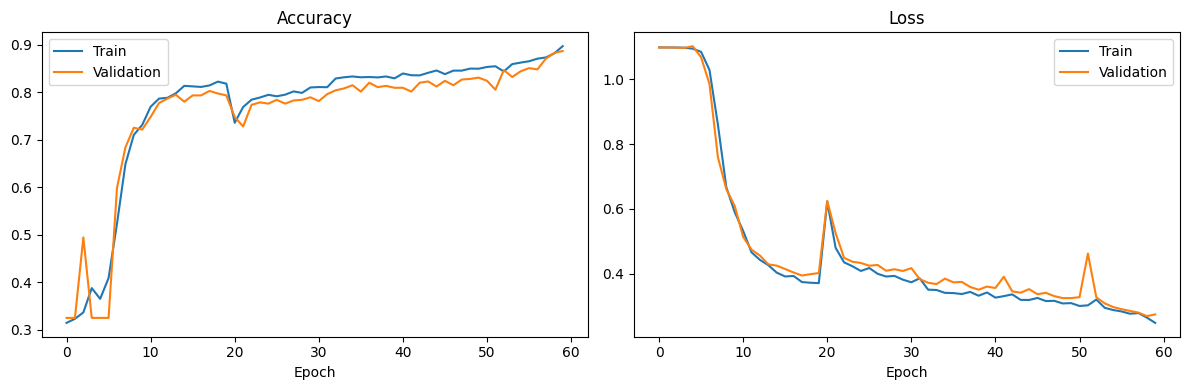

Saved training_history.png


In [20]:
# Load and preprocess
waveforms, labels = load_data(DATA_DIR)
X, Y = preprocess(waveforms, labels, downsample=10)

print(f'X shape: {X.shape}')   # should be (5000, 200, 1)
print(f'Y shape: {Y.shape}')   # should be (5000, 3)

# Train/validation/test split: 70/15/15
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.30, random_state=42, stratify=Y)
X_val,   X_test, Y_val,   Y_test = train_test_split(X_temp, Y_temp, test_size=0.50, random_state=42, stratify=Y_temp)

print(f'Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')

# Build and summarize model
model = build_model(input_length=200)
model.summary()

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))
print('Class weights:', class_weight_dict)

# Train
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=60,
    batch_size=64,
    class_weight=class_weight_dict,
    verbose=1
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=0)
print(f'\nTest accuracy: {test_acc:.4f}')

# Save model
model.save(os.path.join(OUTPUT_DIR, 'cnn_model.h5'))
print('Saved cnn_model.h5')

# Plot training curves
plot_training(history, OUTPUT_DIR)

In [21]:
from sklearn.metrics import classification_report

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)
y_true = np.argmax(Y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=['Noise', 'Single Peak', 'Double Peak']))

24/24 [==============================] - 0s 589us/step
              precision    recall  f1-score   support

       Noise       0.95      1.00      0.98       252
 Single Peak       0.83      0.90      0.87       253
 Double Peak       0.94      0.81      0.87       245

    accuracy                           0.91       750
   macro avg       0.91      0.90      0.90       750
weighted avg       0.91      0.91      0.90       750



In [23]:
# Save final model
model.save(os.path.join(OUTPUT_DIR, 'cnn_model_final.h5'))
print('Saved cnn_model_final.h5')

# Save test set for later verification
np.save(os.path.join(OUTPUT_DIR, 'X_test.npy'), X_test)
np.save(os.path.join(OUTPUT_DIR, 'Y_test.npy'), Y_test)
print('Saved X_test.npy and Y_test.npy')

Saved cnn_model_final.h5
Saved X_test.npy and Y_test.npy
